# How concepts spread: early reach vs keeping fields

**RQ2 of *Exploring emerging scientific concepts through evolving knowledge networks*** (OpenAlex, 12,499 frame concepts).

When a new concept (e.g. *Graphics processing unit*, *Information hiding*) appears in its **home field**, does it end up broadly
integrated across science because it **reaches more off-home fields early**, or because it **keeps** the fields it enters?
This artifact answers that with an **exact log-additive decomposition** of retained off-home breadth eight years after onset:

$$\log B_n = \underbrace{\log E_2}_{\text{early contact (fields entered by } t_0{+}2)} + \underbrace{\log M}_{\text{frontier advance } = E_H/E_2} + \underbrace{\log \rho}_{\text{retention } = B_n/E_H}$$

The gap between the **top** and **bottom** terciles of the integration outcome `O2r_resid` is split into factor shares
(`s_E2`, `s_M`, `s_rho`, which sum to 1), volume-stratified (early-volume quintiles), with concept-bootstrap CIs and
pre-registered verdicts:

* **PR1** – exploration beats retention: `s_explore - s_ret > 0` (Medicine-home concepts excluded). *Full DEV run: SUPPORTED, 0.633 [0.537, 0.727].*
* **PR2** – localised concepts keep more early (retention ratio bottom − top > 0 **and** partial Spearman < 0). *Full DEV run: REVERSED (−0.110); only the partial clause holds (−0.169).*
* **OPEN → PC1** – early ego-network openness correlates with the breadth-of-spread axis PC1 beyond B5 + label coverage. *Full DEV run: partial 0.174.*

**What this notebook does.** The original `method.py` is a *driver* that runs 14 stage scripts over ~25 GB of cached
OpenAlex-derived parquet files (field-state sequences, ego networks, DTW matrices). Those caches cannot ship to Colab, so this
demo (1) shows the driver as-is, then (2) re-runs the **core statistical code of stage S4 (`lib/decomp.py` + `s4_decomp.py`)
and the OPEN-on-PC1 test of S5**, copied verbatim, on a curated sample of **100 DEV concepts** (25 each from CS, Engineering,
Biology/Genetics/Molecular (BGM) and Medicine) whose per-concept inputs (E2, EH, Bn, O2r_resid, B5 baseline, OPEN, PC1) come from
the artifact's output. With 100 instead of 4,771 concepts, point estimates are noisy and CIs are wide; the full-run
numbers are printed next to them for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages are needed for the demo stages (S4 decomposition + S5 OPEN test use numpy/pandas/scipy only).

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The union of the original import blocks of `method.py`, `lib/decomp.py`, `lib/rq1stats.py` and `s4_decomp.py`
(project-internal modules such as `common` are replaced by the constants they provide, defined in the config cell), plus matplotlib for the final figure.

In [2]:
from __future__ import annotations

import argparse
import math
import subprocess
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt

## Data loading
Loads `mini_demo_data.json` from GitHub (works on Colab), falling back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/main/round-4/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["source"])
print("concepts:", len(data["concepts"]))

art_uw4OeagJP3rv full_method_out.json, dataset rq2_concepts (DEV split), 25 concepts per DEV group (CS/Eng/BGM/Med) sampled with seed 20260929; early_volume and label_coverage_early joined from data/joined.parquet by ci
concepts: 100


## Config
All tunable parameters. `N_BOOT` is the number of concept-bootstrap resamples (original: **2,000** = `common.N_BOOT`, also
`N_BOOT_OPEN` in S5). `N_CONCEPTS` caps how many of the 100 demo concepts are used (the original DEV run used all 4,771
DEV concepts, 3,188 with a finite outcome). `SEED` and `B5` are copied from `lib/common.py`.

In [5]:
N_BOOT = 2000        # original: 2000 (common.N_BOOT) — the demo uses the original value
N_BOOT_OPEN = N_BOOT   # original: 2000 (s5_typology.N_BOOT_OPEN)
N_CONCEPTS = 100       # original: all 4,771 DEV concepts (100 = everything in mini_demo_data.json)
SEED = 20260929        # common.SEED
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]   # common.B5: baseline (volume, growth, off-home share, entropy, reach)

## The original driver: `method.py`
This is the artifact's `method.py`, unchanged except that `main()` is **not called**: it launches the 14 stage scripts
(S0 skeleton → S2 OPEN ego-networks → S3 field states → S4 decomposition → S5 typology → S6 sequence test → S7 seal/unseal →
S8 case pairs → S9 AI atlas → S10 outputs → T7 re-derivation → T0 unit tests → audit), which need the full OpenAlex caches.
We print the stage plan instead, then re-run the **S4 core** (and the S5 OPEN test) in the cells below.

In [6]:
ROOT = Path(".").resolve()   # original: Path(__file__).resolve().parent
PY = sys.executable


def steps(workers: int) -> list[tuple[str, list[str]]]:
    return [("S0", ["s0_skeleton.py"]),
            ("S2", ["s2_open.py", "--stage", "all", "--workers", str(workers)]),
            ("S3", ["s3_states.py"]),
            ("S4", ["s4_decomp.py", "--scope", "dev"]),
            ("S5", ["s5_typology.py", "--scope", "dev", "--workers", str(workers)]),
            ("S6", ["s6_sequence.py", "--scope", "dev"]),
            ("S7", ["s7_seal.py", "--freeze"] if not (ROOT / "logs/unsealed.json").exists() else []),
            ("S7run", ["s7_seal.py", "--run"]),
            ("S8", ["s8_cases.py"]),
            ("S9", ["s9_atlas.py"]),
            ("S10", ["s10_outputs.py"]),
            ("T7", ["rederive.py"]),
            ("T0", ["tests/test_units.py"]),
            ("AUDIT", ["audit_headlines.py"])]


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="S0")
    ap.add_argument("--workers", type=int, default=24)
    a = ap.parse_args()
    plan = steps(a.workers)
    names = [n for n, _ in plan]
    for name, cmd in plan[names.index(a.start):]:
        if not cmd:
            print(f"[{name}] skipped (already unsealed)")
            continue
        t = time.time()
        r = subprocess.run([PY, str(ROOT / cmd[0])] + cmd[1:], cwd=ROOT)
        print(f"[{name}] exit {r.returncode} in {time.time() - t:.0f}s")
        if r.returncode != 0:
            sys.exit(r.returncode)


# Notebook: do not run main() (the stage scripts and their caches are not shipped); show the plan instead.
for name, cmd in steps(24):
    print(f"{name:6s} {' '.join(cmd)}")

S0     s0_skeleton.py
S2     s2_open.py --stage all --workers 24
S3     s3_states.py
S4     s4_decomp.py --scope dev
S5     s5_typology.py --scope dev --workers 24
S6     s6_sequence.py --scope dev
S7     s7_seal.py --freeze
S7run  s7_seal.py --run
S8     s8_cases.py
S9     s9_atlas.py
S10    s10_outputs.py
T7     rederive.py
T0     tests/test_units.py
AUDIT  audit_headlines.py


## S4 core: `lib/decomp.py` (verbatim)
The exact decomposition. Per concept: `E2` = off-home fields entered by age 2, `EH` = entered by age 8, `Bn` = fields still
**retained** at age 8. At group level (exact even with zeros): `Ebar = mean E2`, `M_g = ΣEH/ΣE2`, `rho_g = ΣBn/ΣEH`, so mean
breadth `Bbar = Ebar·M_g·rho_g`. `D_k = log f_k(top) − log f_k(bottom)` and `share_k = D_k / Σ D_k` (for a log-additive identity
this equals the Shapley value). Volume strata are merged with neighbours when a factor would be undefined.
`run_variant` recomputes terciles and volume quintiles inside every bootstrap resample.

In [7]:
FACTORS = ["E2", "M", "rho"]
MIN_PER_TERCILE_CI = 30          # fallback 8: fewer concepts per tercile -> no CI, excluded from DL


def terciles(y: np.ndarray, by: np.ndarray | None) -> tuple[np.ndarray, np.ndarray]:
    """top / bottom tercile masks of y, computed within each level of `by` (or the whole sample)."""
    top = np.zeros(len(y), bool)
    bot = np.zeros(len(y), bool)
    levels = [None] if by is None else np.unique(by)
    for g in levels:
        m = np.ones(len(y), bool) if g is None else by == g
        if m.sum() < 3:
            continue
        lo, hi = np.quantile(y[m], [1 / 3, 2 / 3])
        top |= m & (y > hi)
        bot |= m & (y <= lo)
    return top, bot


def quantile_bins(v: np.ndarray, q: int) -> np.ndarray:
    edges = np.quantile(v, np.linspace(0, 1, q + 1)[1:-1])
    return np.searchsorted(edges, v, side="right")


def _factors(E2, EH, Bn) -> tuple[float, float, float]:
    se2, seh, sbn = E2.sum(), EH.sum(), Bn.sum()
    if len(E2) == 0 or se2 <= 0 or seh <= 0 or sbn <= 0:
        return (math.nan,) * 3
    return float(E2.mean()), float(seh / se2), float(sbn / seh)


def _stratum_ok(E2, EH, Bn, t, b) -> bool:
    return t.sum() > 0 and b.sum() > 0 and all(np.isfinite(_factors(E2[m], EH[m], Bn[m])).all() for m in (t, b))


def merge_strata(strata: np.ndarray, E2, EH, Bn, top, bot, family: np.ndarray | None = None) -> tuple[np.ndarray, int]:
    """merge adjacent (ordered) strata until each has valid factors in both terciles; within `family` levels."""
    out = strata.copy()
    merges = 0
    fams = [None] if family is None else np.unique(family)
    for f in fams:
        fm = np.ones(len(strata), bool) if f is None else family == f
        levels = sorted(np.unique(strata[fm]))
        buckets, cur = [], []
        for s in levels:
            cur.append(s)
            m = fm & np.isin(strata, cur)
            if _stratum_ok(E2, EH, Bn, top & m, bot & m):
                buckets.append(cur)
                cur = []
        if cur:
            if buckets:
                buckets[-1] = buckets[-1] + cur
            else:
                buckets.append(cur)
        merges += len(levels) - len(buckets)
        for bk in buckets:
            out[fm & np.isin(strata, bk)] = bk[0]
    return out, merges


def gap(E2, EH, Bn, top, bot, strata: np.ndarray | None = None, family: np.ndarray | None = None) -> dict:
    """D_k (n-weighted over strata), shares, and the unstratified factor levels."""
    if strata is None:
        strata = np.zeros(len(E2), int)
    st, merges = merge_strata(strata, E2, EH, Bn, top, bot, family)
    keys = st * 1000 + (0 if family is None else family)
    Dw = np.zeros(3)
    W = 0.0
    n_str = 0
    for s in np.unique(keys):
        m = keys == s
        t, b = top & m, bot & m
        ft, fb = _factors(E2[t], EH[t], Bn[t]), _factors(E2[b], EH[b], Bn[b])
        if not (np.isfinite(ft).all() and np.isfinite(fb).all()):
            continue
        w = float(t.sum() + b.sum())
        Dw += w * (np.log(ft) - np.log(fb))
        W += w
        n_str += 1
    D = Dw / W if W > 0 else np.full(3, np.nan)
    tot = D.sum()
    sh = D / tot if np.isfinite(tot) and abs(tot) > 1e-12 else np.full(3, np.nan)
    ft, fb = _factors(E2[top], EH[top], Bn[top]), _factors(E2[bot], EH[bot], Bn[bot])
    return {"D_E2": D[0], "D_M": D[1], "D_rho": D[2], "D_total": tot, "s_E2": sh[0], "s_M": sh[1], "s_rho": sh[2],
            "s_explore": sh[0] + sh[1], "s_contact": sh[0], "s_ret": sh[2],
            "diff_explore_ret": (sh[0] + sh[1]) - sh[2], "diff_contact_ret": sh[0] - sh[2],
            "top_Ebar": ft[0], "top_M": ft[1], "top_rho": ft[2], "bot_Ebar": fb[0], "bot_M": fb[1], "bot_rho": fb[2],
            "top_Bbar": float(Bn[top].mean()) if top.any() else math.nan,
            "bot_Bbar": float(Bn[bot].mean()) if bot.any() else math.nan,
            "n_top": int(top.sum()), "n_bot": int(bot.sum()), "n_strata": n_str, "merges": merges}


def das_gupta(E2, EH, Bn, top, bot) -> dict:
    """additive 3-factor Das Gupta decomposition of Bbar(top) - Bbar(bottom) (pooled)."""
    a1, b1, c1 = _factors(E2[top], EH[top], Bn[top])
    a2, b2, c2 = _factors(E2[bot], EH[bot], Bn[bot])

    def eff(x1, x2, y1, y2, z1, z2):
        return (x1 - x2) * ((y1 * z1 + y2 * z2) / 3 + (y1 * z2 + y2 * z1) / 6)
    eA = eff(a1, a2, b1, b2, c1, c2)
    eB = eff(b1, b2, a1, a2, c1, c2)
    eC = eff(c1, c2, a1, a2, b1, b2)
    g = a1 * b1 * c1 - a2 * b2 * c2
    return {"effect_E2": eA, "effect_M": eB, "effect_rho": eC, "gap_Bbar": g, "sum_effects": eA + eB + eC,
            "share_E2": eA / g, "share_M": eB / g, "share_rho": eC / g}


def concept_cov(E2, EH, Bn) -> dict:
    """exact covariance decomposition var(log Bn) = sum_k cov(log Bn, log f_k) among Bn >= 1."""
    m = (Bn >= 1) & (E2 >= 1)
    lb = np.log(Bn[m])
    le, lm, lr = np.log(E2[m]), np.log(EH[m] / E2[m]), np.log(Bn[m] / EH[m])
    v = lb.var()
    cs = [float(np.cov(lb, x, bias=True)[0, 1]) for x in (le, lm, lr)]
    return {"n": int(m.sum()), "var_logBn": float(v), "cov_E2": cs[0], "cov_M": cs[1], "cov_rho": cs[2],
            "share_E2": cs[0] / v, "share_M": cs[1] / v, "share_rho": cs[2] / v,
            "identity_max_abs_err": float(np.max(np.abs(lb - (le + lm + lr)))) if m.any() else 0.0}


def run_variant(d: dict, spec: dict, rng: np.random.Generator | None, n_boot: int) -> dict:
    """d: arrays E2, EH, Bn, y (tercile outcome), logvol_early, med, tby (tercile-within levels or None),
    rs (resampling strata, e.g. unit). spec: strata in {none, vol, vol_med}."""
    def once(idx: np.ndarray | None) -> dict:
        g = (lambda a: a) if idx is None else (lambda a: None if a is None else a[idx])  # noqa: E731
        E2, EH, Bn, y = g(d["E2"]), g(d["EH"]), g(d["Bn"]), g(d["y"])
        top, bot = terciles(y, g(d.get("tby")))
        strata = family = None
        if spec["strata"] in ("vol", "vol_med"):
            lv = g(d["logvol_early"])
            tb = g(d.get("tby"))
            if tb is None:
                strata = quantile_bins(lv, 5)
            else:  # quintiles within each tercile-level (unit) so strata never mix units
                strata = np.zeros(len(lv), int)
                for u in np.unique(tb):
                    m = tb == u
                    strata[m] = quantile_bins(lv[m], 5)
                family = np.unique(tb, return_inverse=True)[1]
        if spec["strata"] == "vol_med":
            med = g(d["med"]).astype(int)
            family = med if family is None else family * 2 + med
        return gap(E2, EH, Bn, top, bot, strata, family)
    point = once(None)
    out = {"point": point, "n": int(len(d["E2"]))}
    if rng is None or n_boot <= 0:
        return out
    n = len(d["E2"])
    rs = d.get("rs")
    groups = [np.arange(n)] if rs is None else [np.nonzero(rs == u)[0] for u in np.unique(rs)]
    keys = ["D_E2", "D_M", "D_rho", "D_total", "s_E2", "s_M", "s_rho", "s_explore", "s_contact", "s_ret",
            "diff_explore_ret", "diff_contact_ret"]
    B = {k: np.empty(n_boot) for k in keys}
    for b in range(n_boot):
        idx = np.concatenate([gi[rng.integers(0, len(gi), len(gi))] for gi in groups])
        r = once(idx)
        for k in keys:
            B[k][b] = r[k]
    out["ci"] = {k: [float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5))] for k, v in B.items()}
    out["se"] = {k: float(np.nanstd(v, ddof=1)) for k, v in B.items()}
    out["p_two_sided"] = {k: float(min(1.0, 2 * min(np.nanmean(v <= 0), np.nanmean(v >= 0)))) for k, v in B.items()}
    out["boot_nan_share"] = float(np.mean(~np.isfinite(B["s_ret"])))
    out["_boot"] = B
    return out


def verdict(ci: list[float]) -> str:
    lo, hi = ci
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return "NOT EVALUABLE"
    if lo > 0:
        return "SUPPORTED"
    if hi < 0:
        return "REVERSED"
    return "NOT SUPPORTED"


# Notebook: s4_decomp.py imports this file as `import decomp as DC`; expose the same names under DC.
import types
DC = types.SimpleNamespace(**{k: globals()[k] for k in ("FACTORS", "MIN_PER_TERCILE_CI", "terciles", "quantile_bins", "gap",
                                                       "das_gupta", "concept_cov", "run_variant", "verdict")})

## Partial Spearman with bootstrap: `lib/rq1stats.py` (verbatim excerpt)
`holm` (Holm step-down adjustment of the PR1/PR1b/PR2 family) is included too. Partial Spearman is used by PR2 (retention ratio vs `O2r_resid`, given B5) and by the OPEN test: both variables are ranked, residualised on the
ranked covariates, and correlated; ranks and residualisation are recomputed in each bootstrap resample.

In [8]:
# ----------------------------------------------------------------------------- partial Spearman
def dummies(v: np.ndarray, drop_first: bool = True) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    cols = u[1:] if drop_first else u
    return (v[:, None] == cols[None, :]).astype(float)


def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    """Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample)."""
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


def sign_test_two_sided(k_pos: int, n: int) -> float:
    return float(stats.binomtest(k_pos, n, 0.5).pvalue) if n > 0 else float("nan")

## Build the concept table (replaces `s4_decomp.load_table`)
The original merges `data/joined.parquet`, `data/decomp_inputs.parquet` and the EXP8 outcomes. Here the same columns are built
from `data`: counts `E2/EH/Bn`, outcome `O2r_resid`, `med_home`, `logvol_early = log(early_volume)`, the B5 baseline,
`RETENTION_RATIO_early` (+ its missing flag), label coverage, OPEN (3 builds) and the trajectory-continuum axis PC1.

In [9]:
rows = []
for c in data["concepts"][:N_CONCEPTS]:
    r = {k: v for k, v in c.items() if k not in ("B5", "predict_decomposition")}
    r.update(c["B5"])
    rows.append(r)
T = pd.DataFrame(rows)
T["O2r_resid"] = T.O2r_resid.astype(float)
T["RETENTION_RATIO_missing"] = T.RETENTION_RATIO_early.isna().astype(int)
T["RETENTION_RATIO_early"] = T.RETENTION_RATIO_early.astype(float)
T["logvol_early"] = np.log(T.early_volume)
print(T.shape)
print(T.groupby("group")[["E2", "EH", "Bn", "O2r_resid"]].mean().round(2))
T[["name", "group", "E2", "EH", "Bn", "O2r_resid", "O2r_resid_tercile", "OPEN_all", "PC1"]].head(8)

(100, 31)
         E2    EH    Bn  O2r_resid
group                             
BGM    3.44  5.56  3.24       0.61
CS     3.08  5.20  2.96       0.31
Eng    4.04  6.20  3.00       0.70
Med    2.04  3.96  2.08      -0.42


,name,group,E2,EH,Bn,O2r_resid,O2r_resid_tercile,OPEN_all,PC1
0,Information hiding,CS,2,4,2,-1.638858,bottom,-0.066688,3.771323
1,Shortest path problem,CS,4,6,3,0.548048,top,-0.090523,6.750677
2,Vertex cover,CS,4,4,4,0.541259,top,-0.157247,2.795039
3,Semi-supervised learning,CS,3,4,1,1.075651,top,0.137009,2.420625
4,Crowdsourcing,CS,7,17,15,5.308775,top,3.640158,13.781626
5,Graph coloring,CS,4,5,4,1.552399,top,-0.314238,5.032891
6,Multi-core processor,CS,2,8,6,-0.379364,middle,1.328767,3.531272
7,Apriori algorithm,CS,2,6,3,0.055882,middle,0.005552,3.629138


### Sanity check: the identity holds per concept
For every concept with `E2, Bn ≥ 1`, `log Bn = log E2 + log M + log rho` exactly (the artifact's `predict_decomposition` field stores these three terms).

In [10]:
ok = (T.Bn >= 1) & (T.E2 >= 1)
lhs = np.log(T.Bn[ok])
rhs = np.log(T.E2[ok]) + np.log(T.EH[ok] / T.E2[ok]) + np.log(T.Bn[ok] / T.EH[ok])
stored = np.array([sum(c["predict_decomposition"].values()) for c, m in zip(data["concepts"][:N_CONCEPTS], ok) if m])
print(f"{ok.sum()} concepts with E2,Bn>=1; max |identity error| = {np.max(np.abs(lhs - rhs)):.2e}; "
      f"max |stored - log Bn| = {np.max(np.abs(stored - lhs.to_numpy())):.2e}")

90 concepts with E2,Bn>=1; max |identity error| = 4.44e-16; max |stored - log Bn| = 9.12e-07


## S4 analysis: `s4_decomp.py` (verbatim functions)
Pre-registration text, the decomposition variants, the per-variant bootstrap job, PR2's early-retention test, and `analyze`.
Minimal notebook changes: only the four variants whose count columns are in the demo data are kept (the `min_n`, `O2r_m50`,
`O1b`, onset-restricted and no-EXP6 robustness variants need extra count columns), and `ProcessPoolExecutor` is replaced by
the built-in `map` (the jobs are tiny at 100 concepts, and worker processes cannot pickle notebook-defined functions everywhere).

In [11]:
PREREG = {
    "PR1": ("EXPLORATION > RETENTION: in variant (iv) [volume-stratified (early-volume quintiles), concepts with a "
            "Medicine (field 27) home excluded], s_explore - s_ret > 0 with the 95% concept-bootstrap CI > 0, where "
            "s_explore = s_E2 + s_M and s_ret = s_rho are the shares of the top-vs-bottom O2r_resid tercile gap in "
            "log mean breadth (Bn = retained off-home fields at t0+8). Equivalently s_ret < 0.5; both are printed "
            "(shares sum to 1)."),
    "PR1b": "(secondary, Holm family R2-A with PR1 and PR2): s_contact - s_ret > 0 with CI > 0 (s_contact = s_E2).",
    "PR2": ("LOCALISED KEEP MORE EARLY: mean RETENTION_RATIO_early(bottom O2r_resid tercile) - mean(top tercile) > 0 "
            "with CI > 0, AND the partial Spearman of RETENTION_RATIO_early with O2r_resid given B5 < 0 (CI < 0). The "
            "latter is flagged 'replication on the same frame as EXP8, not new evidence'."),
    "PR3": "(descriptive, not tested): the sign of D_rho, i.e. whether late retention probability is lower for "
           "integrating (top-tercile) concepts.",
    "verdict_rule": "per clause: SUPPORTED (CI on the predicted side) / NOT SUPPORTED (CI covers 0) / REVERSED "
                    "(CI on the opposite side); evaluated separately on DEV and on held-out.",
    "holm_family_R2A": ["PR1", "PR1b", "PR2"],
}

VARIANTS = {   # name: (strata, subset, y column, decomp suffix)
    "i_pooled": ("none", None, "O2r_resid", ""),
    "ii_vol_PRIMARY": ("vol", None, "O2r_resid", ""),
    "iii_vol_med_adjusted": ("vol_med", None, "O2r_resid", ""),
    "iv_vol_noMed_PR1": ("vol", "nomed", "O2r_resid", ""),
    # --- not reproducible from the demo data (need extra count columns); kept for reference:
    # "v_minn3": ("vol", None, "O2r_resid", "_mn3"),
    # "v_minn5": ("vol", None, "O2r_resid", "_mn5"),
    # "v_minn3_noMed": ("vol", "nomed", "O2r_resid", "_mn3"),
    # "v_minn5_noMed": ("vol", "nomed", "O2r_resid", "_mn5"),
    # "vi_O2r_m50": ("vol", None, "O2r_m50", ""),
    # "vi_O1b_sustained_only": ("vol", "o1b", "O2r_resid", ""),
    # "viii_onset_restricted": ("vol", None, "O2r_resid", "_onset"),
    # "viii_onset_restricted_noMed": ("vol", "nomed", "O2r_resid", "_onset"),
    # "ix_noEXP6_noMed": ("vol", "noexp6_nomed", "O2r_resid", ""),
}
BOOT_KEYS = ["D_E2", "D_M", "D_rho", "diff_explore_ret", "diff_contact_ret", "s_ret"]

In [12]:
def arrays(T: pd.DataFrame, suffix: str, ycol: str, tby=None, rs=None) -> dict:
    return {"E2": T[f"E2{suffix}"].to_numpy(float), "EH": T[f"EH{suffix}"].to_numpy(float),
            "Bn": T[f"Bn{suffix}"].to_numpy(float), "y": T[ycol].to_numpy(float),
            "logvol_early": T.logvol_early.to_numpy(float), "med": T.med_home.to_numpy(int),
            "tby": None if tby is None else T[tby].to_numpy(), "rs": None if rs is None else T[rs].to_numpy()}


def subset(T: pd.DataFrame, which: str | None) -> pd.DataFrame:
    if which is None:
        return T
    if which == "nomed":
        return T[T.med_home == 0]
    if which == "o1b":   # plan says 'O1c = 1'; O1c is continuous in EXP8, the binary sustained-uptake outcome is O1b
        return T[T.O1b == 1]
    if which == "noexp6_nomed":
        return T[(T.med_home == 0) & (T.in_exp6 == 0)]
    raise ValueError(which)


def _job(args):
    name, T, spec, tby, rs, seed, n_boot = args
    strata, sub, ycol, suf = spec
    S = subset(T, sub)
    S = S[np.isfinite(S[ycol])]
    res = DC.run_variant(arrays(S, suf, ycol, tby, rs), {"strata": strata}, np.random.default_rng(seed), n_boot)
    B = res.pop("_boot", None)
    res["boot_quantiles"] = {k: np.nanpercentile(B[k], [2.5, 5, 25, 50, 75, 95, 97.5]).tolist()
                             for k in BOOT_KEYS} if B is not None else None
    res["spec"] = {"strata": strata, "subset": sub, "y": ycol, "counts_suffix": suf or "min_n=2"}
    tn = min(res["point"]["n_top"], res["point"]["n_bot"])
    res["ci_reported"] = tn >= DC.MIN_PER_TERCILE_CI
    return name, res


def early_ratio(T: pd.DataFrame, seed: int, n_boot: int, tby=None) -> dict:
    """PR2: RETENTION_RATIO_early bottom - top tercile (concepts with >= 1 off-home contact) + psp given B5."""
    S = T[np.isfinite(T.O2r_resid) & (T.RETENTION_RATIO_missing == 0)]
    y = S.O2r_resid.to_numpy()
    rr = S.RETENTION_RATIO_early.to_numpy()
    tb = None if tby is None else S[tby].to_numpy()
    rng = np.random.default_rng(seed)

    def diff(idx):
        top, bot = DC.terciles(y[idx], None if tb is None else tb[idx])
        return rr[idx][bot].mean() - rr[idx][top].mean()
    n = len(S)
    pt = diff(np.arange(n))
    bs = np.array([diff(rng.integers(0, n, n)) for _ in range(n_boot)])
    ps = psp_boot(rr, y, S[B5].to_numpy(float), None, n_boot, seed + 7)
    top, bot = DC.terciles(y, tb)
    return {"n": n, "mean_bottom": float(rr[bot].mean()), "mean_top": float(rr[top].mean()),
            "diff_bottom_minus_top": float(pt), "ci": np.percentile(bs, [2.5, 97.5]).tolist(),
            "se": float(bs.std(ddof=1)), "p_two_sided": float(min(1, 2 * min((bs <= 0).mean(), (bs >= 0).mean()))),
            "psp_given_B5": {k: ps[k] for k in ("n", "rho", "ci", "se", "p")},
            "note_psp": "replication on the same frame as EXP8, not new evidence"}


def analyze(T: pd.DataFrame, label: str, seed: int, tby=None, rs=None, n_boot: int = N_BOOT,
            variants=VARIANTS, workers: int = 13) -> dict:
    jobs = [(name, T, spec, tby, rs, seed + k, n_boot) for k, (name, spec) in enumerate(variants.items())]
    # original: with ProcessPoolExecutor(min(workers, len(jobs))) as ex: res = dict(ex.map(_job, jobs))
    res = dict(map(_job, jobs))
    out = {"label": label, "n_concepts_with_outcome": int(np.isfinite(T.O2r_resid).sum()), "variants": res}
    S = T[np.isfinite(T.O2r_resid)]
    top, bot = DC.terciles(S.O2r_resid.to_numpy(), None if tby is None else S[tby].to_numpy())
    a = arrays(S, "", "O2r_resid")
    out["das_gupta_pooled"] = DC.das_gupta(a["E2"], a["EH"], a["Bn"], top, bot)
    out["concept_level_cov"] = DC.concept_cov(a["E2"], a["EH"], a["Bn"])
    out["early_ratio_PR2"] = early_ratio(T, seed + 99, n_boot, tby)
    out["early_ratio_PR2_noMed"] = early_ratio(T[T.med_home == 0], seed + 98, n_boot, tby)
    return out


def verdicts(res: dict) -> dict:
    v = res["variants"]["iv_vol_noMed_PR1"]
    er = res["early_ratio_PR2"]
    p1 = v["p_two_sided"]["diff_explore_ret"]
    p1b = v["p_two_sided"]["diff_contact_ret"]
    p2 = max(er["p_two_sided"], er["psp_given_B5"]["p"])
    ph = holm([p1, p1b, p2])
    pr2a = DC.verdict(er["ci"])
    pr2b = DC.verdict([-er["psp_given_B5"]["ci"][1], -er["psp_given_B5"]["ci"][0]])
    pr2 = "SUPPORTED" if (pr2a == pr2b == "SUPPORTED") else ("REVERSED" if "REVERSED" in (pr2a, pr2b)
                                                              else "NOT SUPPORTED")
    return {"PR1": {"verdict": DC.verdict(v["ci"]["diff_explore_ret"]), "s_explore_minus_s_ret": v["point"]["diff_explore_ret"],
                    "ci": v["ci"]["diff_explore_ret"], "s_ret": v["point"]["s_ret"], "s_ret_ci": v["ci"]["s_ret"],
                    "s_ret_below_0.5": bool(v["ci"]["s_ret"][1] < 0.5), "p": p1, "p_holm": ph[0]},
            "PR1b": {"verdict": DC.verdict(v["ci"]["diff_contact_ret"]), "s_contact_minus_s_ret": v["point"]["diff_contact_ret"],
                     "ci": v["ci"]["diff_contact_ret"], "p": p1b, "p_holm": ph[1]},
            "PR2": {"verdict": pr2, "clause_diff": pr2a, "clause_psp_negative": pr2b, "p_iut": p2, "p_holm": ph[2],
                    "diff": er["diff_bottom_minus_top"], "diff_ci": er["ci"], "psp": er["psp_given_B5"]["rho"],
                    "psp_ci": er["psp_given_B5"]["ci"]},
            "PR3_descriptive": {"D_rho": v["point"]["D_rho"], "ci": v["ci"]["D_rho"],
                                "sign": "negative (integrating concepts keep a SMALLER share of entered fields)"
                                if v["point"]["D_rho"] < 0 else "positive (integrating concepts keep a LARGER share)"}}

## Run S4 on the demo DEV sample
Same call as `s4_decomp.main()` for `--scope dev`: `analyze(T, "DEV", SEED + 400)` then `verdicts(...)`, plus the per-group
primary variant. With ~33 concepts per tercile (25 without Medicine) the CI rule `MIN_PER_TERCILE_CI = 30` flags small groups.

In [13]:
t = time.time()
res = analyze(T, "DEV", SEED + 400, n_boot=N_BOOT)
res["verdicts"] = verdicts(res)
print(f"S4 done in {time.time() - t:.1f}s  (n_boot={N_BOOT})")
v = res["verdicts"]
print(f"DEV PR1 {v['PR1']['verdict']} diff {v['PR1']['s_explore_minus_s_ret']:.3f} {np.round(v['PR1']['ci'], 3).tolist()}; "
      f"PR1b {v['PR1b']['verdict']}; PR2 {v['PR2']['verdict']} ({v['PR2']['clause_diff']}, "
      f"{v['PR2']['clause_psp_negative']}); D_rho {v['PR3_descriptive']['D_rho']:.3f}")

S4 done in 4.5s  (n_boot=2000)
DEV PR1 NOT SUPPORTED diff 0.606 [-0.054, 1.384]; PR1b NOT SUPPORTED; PR2 NOT SUPPORTED (NOT SUPPORTED, NOT SUPPORTED); D_rho 0.154


In [14]:
import warnings
# early_ratio_PR2_noMed on the Medicine-only group has zero rows -> harmless 'Mean of empty slice' warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
res["dev_groups"] = {g: analyze(T[T.group == g], f"DEV_{g}", SEED + 410 + k, n_boot=N_BOOT,
                                variants={kk: VARIANTS[kk] for kk in ("ii_vol_PRIMARY", "i_pooled")})
                     for k, g in enumerate(["CS", "Eng", "BGM", "Med"])}
for g, r in res["dev_groups"].items():
    p = r["variants"]["ii_vol_PRIMARY"]["point"]
    print(f"{g:4s} n_top={p['n_top']:2d} n_bot={p['n_bot']:2d}  D_E2={p['D_E2']:+.3f} D_M={p['D_M']:+.3f} D_rho={p['D_rho']:+.3f}")

CS   n_top= 8 n_bot= 9  D_E2=+0.530 D_M=+0.179 D_rho=+0.032
Eng  n_top= 8 n_bot= 9  D_E2=+0.369 D_M=+0.228 D_rho=+0.649
BGM  n_top= 8 n_bot= 9  D_E2=+0.502 D_M=+0.058 D_rho=+0.267
Med  n_top= 8 n_bot= 9  D_E2=+1.224 D_M=-0.379 D_rho=+0.994


## S5 excerpt: does early ego-network openness predict the breadth-of-spread axis?
`open_on_axis` from `s5_typology.py` (verbatim): raw and partial Spearman of `OPEN_{all,home,size}` with the trajectory-continuum
axis PC1, the partial one controlling for B5 + early label coverage. (PC1 itself comes from the PCA over all 4,771 DEV
field-state trajectories and is taken from the artifact output.)

In [15]:
BUILDS = ("all", "home", "size")


def open_on_axis(T: pd.DataFrame, axis: str, seed: int, n_boot: int = N_BOOT_OPEN) -> dict:
    out = {}
    cov = T[B5 + ["label_coverage_early"]].to_numpy(float)
    for k, b in enumerate(BUILDS):
        x = T[f"OPEN_{b}"].to_numpy(float)
        y = T[axis].to_numpy(float)
        raw = psp_boot(x, y, None, None, n_boot, seed + 10 * k)
        par = psp_boot(x, y, cov, None, n_boot, seed + 10 * k + 1)
        out[b] = {"spearman": {kk: raw[kk] for kk in ("n", "rho", "ci", "se", "p")},
                  "partial_given_B5_labelcov": {kk: par[kk] for kk in ("n", "rho", "ci", "se", "p")}}
    return out


t = time.time()
open_res = open_on_axis(T, "PC1", SEED + 50, n_boot=N_BOOT_OPEN)
print(f"OPEN on PC1 done in {time.time() - t:.1f}s")
for b in BUILDS:
    r = open_res[b]
    print(f"OPEN_{b:4s}: Spearman {r['spearman']['rho']:+.3f} {np.round(r['spearman']['ci'], 3).tolist()}  "
          f"partial|B5+labcov {r['partial_given_B5_labelcov']['rho']:+.3f} {np.round(r['partial_given_B5_labelcov']['ci'], 3).tolist()}")

OPEN on PC1 done in 2.5s
OPEN_all : Spearman +0.229 [0.039, 0.41]  partial|B5+labcov +0.080 [-0.164, 0.293]
OPEN_home: Spearman +0.143 [-0.071, 0.337]  partial|B5+labcov +0.219 [0.001, 0.405]
OPEN_size: Spearman +0.001 [-0.201, 0.199]  partial|B5+labcov +0.200 [-0.017, 0.383]


## Results
Demo (100 concepts) versus the full DEV run (4,771 concepts, 3,188 with an outcome). Expect the same *direction* for the
headline quantities, with much wider intervals: the decomposition shares are ratios of small log-differences, so with ~25
concepts per tercile they move a lot between samples.

In [16]:
ref = data["metadata"]["full_DEV_reference"]
rows = []
for name in VARIANTS:
    p = res["variants"][name]["point"]; ci = res["variants"][name].get("ci", {})
    rows.append({"variant": name, "n_top": p["n_top"], "n_bot": p["n_bot"], "s_E2": p["s_E2"], "s_M": p["s_M"], "s_rho": p["s_rho"],
                 "s_explore-s_ret": p["diff_explore_ret"], "CI": np.round(ci.get("diff_explore_ret", [np.nan] * 2), 3).tolist(),
                 "D_rho": p["D_rho"], "top_Bbar": p["top_Bbar"], "bot_Bbar": p["bot_Bbar"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

v = res["verdicts"]
summary = pd.DataFrame([
    ["PR1: s_explore - s_ret (noMed, vol-strat.)", v["PR1"]["s_explore_minus_s_ret"], v["PR1"]["ci"], v["PR1"]["verdict"],
     ref["PR1_DEV_s_explore_minus_s_ret"], "SUPPORTED"],
    ["PR2a: retention ratio bottom - top", v["PR2"]["diff"], v["PR2"]["diff_ci"], v["PR2"]["clause_diff"], ref["PR2_DEV_diff"], "REVERSED"],
    ["PR2b: partial Spearman RR ~ O2r | B5", v["PR2"]["psp"], v["PR2"]["psp_ci"], v["PR2"]["clause_psp_negative"], ref["PR2_DEV_psp"], "SUPPORTED"],
    ["OPEN_all ~ PC1 | B5 + label cov.", open_res["all"]["partial_given_B5_labelcov"]["rho"],
     open_res["all"]["partial_given_B5_labelcov"]["ci"], "", ref["OPEN_PC1_DEV_partial_all"], ""],
], columns=["quantity", "demo", "demo 95% CI", "demo verdict", "full DEV", "full verdict"])
summary["demo"] = summary["demo"].round(3); summary["demo 95% CI"] = summary["demo 95% CI"].map(lambda c: np.round(c, 3).tolist())
print(); print(summary.to_string(index=False))

             variant  n_top  n_bot  s_E2   s_M  s_rho  s_explore-s_ret              CI  D_rho  top_Bbar  bot_Bbar
            i_pooled     33     34 0.609 0.038  0.353            0.293  [0.023, 0.743]  0.412     4.242     1.324
      ii_vol_PRIMARY     33     34 0.641 0.009  0.350            0.300   [-0.054, 0.8]  0.404     4.242     1.324
iii_vol_med_adjusted     33     34 0.574 0.042  0.384            0.233 [-0.055, 0.856]  0.451     4.242     1.324
    iv_vol_noMed_PR1     25     25 0.589 0.213  0.197            0.606 [-0.054, 1.384]  0.154     4.200     2.080

                                  quantity   demo     demo 95% CI  demo verdict  full DEV full verdict
PR1: s_explore - s_ret (noMed, vol-strat.)  0.606 [-0.054, 1.384] NOT SUPPORTED  0.632654    SUPPORTED
        PR2a: retention ratio bottom - top  0.055 [-0.105, 0.204] NOT SUPPORTED -0.109856     REVERSED
      PR2b: partial Spearman RR ~ O2r | B5 -0.130 [-0.295, 0.055] NOT SUPPORTED -0.168768    SUPPORTED
          OPEN_al

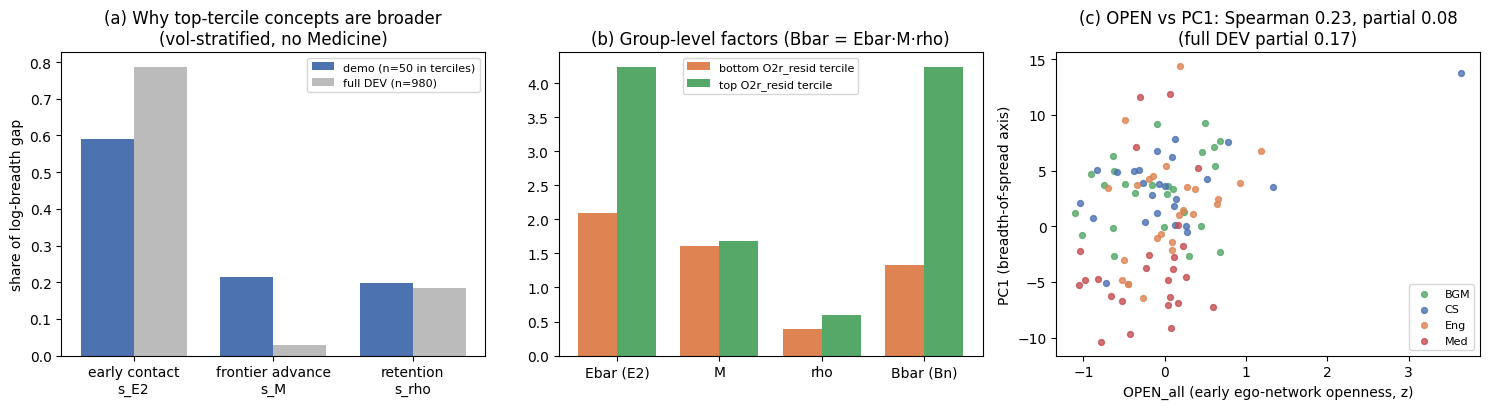

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) factor shares of the top-vs-bottom breadth gap: demo PR1 variant vs full DEV PR1 variant
p = res["variants"]["iv_vol_noMed_PR1"]["point"]
full = ref["shares_DEV_PR1_variant"]
x = np.arange(3); w = 0.38
axes[0].bar(x - w / 2, [p["s_E2"], p["s_M"], p["s_rho"]], w, label=f"demo (n={p['n_top'] + p['n_bot']} in terciles)", color="#4C72B0")
axes[0].bar(x + w / 2, [full["s_E2"], full["s_M"], full["s_rho"]], w, label="full DEV (n=980)", color="#BBBBBB")
axes[0].set_xticks(x, ["early contact\ns_E2", "frontier advance\ns_M", "retention\ns_rho"])
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_ylabel("share of log-breadth gap")
axes[0].set_title("(a) Why top-tercile concepts are broader\n(vol-stratified, no Medicine)"); axes[0].legend(fontsize=8)

# (b) factor levels top vs bottom tercile (pooled variant)
p0 = res["variants"]["i_pooled"]["point"]
lab = ["Ebar (E2)", "M", "rho", "Bbar (Bn)"]
axes[1].bar(np.arange(4) - w / 2, [p0["bot_Ebar"], p0["bot_M"], p0["bot_rho"], p0["bot_Bbar"]], w, label="bottom O2r_resid tercile", color="#DD8452")
axes[1].bar(np.arange(4) + w / 2, [p0["top_Ebar"], p0["top_M"], p0["top_rho"], p0["top_Bbar"]], w, label="top O2r_resid tercile", color="#55A868")
axes[1].set_xticks(np.arange(4), lab); axes[1].set_title("(b) Group-level factors (Bbar = Ebar·M·rho)"); axes[1].legend(fontsize=8)

# (c) OPEN vs PC1
cols = {"CS": "#4C72B0", "Eng": "#DD8452", "BGM": "#55A868", "Med": "#C44E52"}
for g, S in T.groupby("group"):
    axes[2].scatter(S.OPEN_all, S.PC1, s=18, alpha=0.8, label=g, color=cols[g])
r = open_res["all"]
axes[2].set_xlabel("OPEN_all (early ego-network openness, z)"); axes[2].set_ylabel("PC1 (breadth-of-spread axis)")
axes[2].set_title(f"(c) OPEN vs PC1: Spearman {r['spearman']['rho']:.2f}, partial {r['partial_given_B5_labelcov']['rho']:.2f}\n"
                  f"(full DEV partial {ref['OPEN_PC1_DEV_partial_all']:.2f})")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the results.** In the full run, top-tercile (broadly integrating) concepts are broader at age 8 mainly because they
**touched more off-home fields in the first two years** (`s_E2 ≈ 0.79`); frontier advance after age 2 contributes almost nothing
(`s_M ≈ 0.03`); and retention adds a smaller, *positive* part (`s_rho ≈ 0.18`): integrating concepts also keep a larger share
of the fields they enter, the opposite of "localised concepts keep more" (PR2 reversed). Early openness of the concept's
ego-network tracks the breadth axis beyond volume/growth/reach.

**On the 100-concept demo** (original `N_BOOT = 2000`), the PR1 point estimate `s_explore − s_ret ≈ 0.61` is close to the full
run's 0.63 and early contact again dominates the shares, but with only 25 concepts per tercile every interval covers 0,
so the demo verdicts read NOT SUPPORTED. That is a power limit of the subsample, not a contradiction. To recover the published
intervals, run the same cells on the full DEV concept table (`N_CONCEPTS` = all 4,771 concepts) via the original `method.py` pipeline.